In [1]:
# fusion.ipynb — Cell 1: Imports + Load
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Load all saved files
ecg_data  = np.load('ecg_waveforms_final.npy')
text_data = np.load('text_embeddings_final.npy')
clin_data = np.load('clinical_features_final.npy')
labels    = np.load('labels_final.npy')
idx_train = np.load('idx_train.npy')
idx_val   = np.load('idx_val.npy')
idx_test  = np.load('idx_test.npy')
clin_train = np.load('clin_train.npy')
clin_val   = np.load('clin_val.npy')
clin_test  = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

print("All files loaded!")
print(f"ECG    : {ecg_data.shape}")
print(f"Text   : {text_data.shape}")
print(f"Clin   : {clin_data.shape}")
print(f"Labels : {labels.shape}")
print(f"Train/Val/Test: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")

All files loaded!
ECG    : (16203, 5000)
Text   : (16203, 768)
Clin   : (16203, 7)
Labels : (16203,)
Train/Val/Test: 11341/1621/3241


In [2]:
# ── Model definitions
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      stride=stride, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(out_ch, out_ch, kernel,
                      stride=1, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride),
            nn.BatchNorm1d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))


class ECGEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.layers = nn.Sequential(
            ResBlock1D(64,  64,  7),
            ResBlock1D(64,  128, 5, stride=2),
            ResBlock1D(128, 256, 3, stride=2),
            ResBlock1D(256, 256, 3),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embed_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.proj(self.pool(self.layers(self.entry(x))))


class TextEncoder(nn.Module):
    def __init__(self, in_dim=768, out_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, out_dim), nn.ReLU(), nn.Dropout(0.2)
        )

    def forward(self, x):
        return self.proj(x)


class ClinicalEncoder(nn.Module):
    def __init__(self, in_dim=7, out_dim=64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.proj(x)


# ── Context-Gated Attention — Core Innovation
class ContextGatedAttention(nn.Module):
    def __init__(self, ecg_dim=256, text_dim=256, clin_dim=64):
        super().__init__()
        ctx_dim = ecg_dim + text_dim + clin_dim   # 576

        self.context_enc = nn.Sequential(
            nn.Linear(ctx_dim, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),    nn.ReLU()
        )
        # Per-modality gates
        self.gate_ecg  = nn.Linear(128, ecg_dim)
        self.gate_text = nn.Linear(128, text_dim)
        self.gate_clin = nn.Linear(128, clin_dim)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, ecg_emb, text_emb, clin_emb):
        ctx     = torch.cat([ecg_emb, text_emb, clin_emb], dim=1)
        ctx_vec = self.context_enc(ctx)

        ecg_w  = self.sigmoid(self.gate_ecg(ctx_vec))  * ecg_emb
        text_w = self.sigmoid(self.gate_text(ctx_vec)) * text_emb
        clin_w = self.sigmoid(self.gate_clin(ctx_vec)) * clin_emb

        return ecg_w, text_w, clin_w, ctx_vec


# ── Full Fusion Model
class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.ecg_enc  = ECGEncoder(embed_dim=256)
        self.text_enc = TextEncoder(in_dim=768, out_dim=256)
        self.clin_enc = ClinicalEncoder(in_dim=7, out_dim=64)
        self.cga      = ContextGatedAttention(256, 256, 64)

        # 256 + 256 + 64 + 128 = 704
        self.classifier = nn.Sequential(
            nn.Linear(704, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, ecg, text, clin):
        ecg_emb  = self.ecg_enc(ecg)
        text_emb = self.text_enc(text)
        clin_emb = self.clin_enc(clin)

        ecg_w, text_w, clin_w, ctx = self.cga(
            ecg_emb, text_emb, clin_emb
        )
        fused = torch.cat([ecg_w, text_w, clin_w, ctx], dim=1)
        return self.classifier(fused)


# ── Setup
device = torch.device('cuda')
model  = MultimodalFusionModel(num_classes=3)
model  = nn.DataParallel(model)
model  = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

# Quick test
ecg_t  = torch.randn(4, 1, 5000).to(device)
text_t = torch.randn(4, 768).to(device)
clin_t = torch.randn(4, 7).to(device)
out    = model(ecg_t, text_t, clin_t)
print(f"Output shape: {out.shape}")
print("✅ Model test passed!")

Parameters: 1,977,731
Output shape: torch.Size([4, 3])
✅ Model test passed!


In [3]:
# ── DataLoaders
def make_loader(ecg_idx, text_idx, clin_scaled,
                y_labels, batch_size=32, shuffle=True):
    ecg_t  = torch.tensor(
        ecg_data[ecg_idx], dtype=torch.float32
    ).unsqueeze(1)
    text_t = torch.tensor(
        text_data[text_idx], dtype=torch.float32
    )
    clin_t = torch.tensor(clin_scaled, dtype=torch.float32)
    y_t    = torch.tensor(y_labels,    dtype=torch.long)

    return DataLoader(
        TensorDataset(ecg_t, text_t, clin_t, y_t),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=True,
        num_workers=0
    )

train_loader = make_loader(
    idx_train, idx_train, clin_train,
    labels[idx_train], shuffle=True
)
val_loader   = make_loader(
    idx_val, idx_val, clin_val,
    labels[idx_val], shuffle=False
)
test_loader  = make_loader(
    idx_test, idx_test, clin_test,
    labels[idx_test], shuffle=False
)

print(f"Train : {len(train_loader)} batches")
print(f"Val   : {len(val_loader)} batches")
print(f"Test  : {len(test_loader)} batches")

Train : 355 batches
Val   : 51 batches
Test  : 102 batches


In [4]:
# ── Training
cw        = torch.tensor(
    class_weights, dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(
    weight=cw, label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

EPOCHS   = 50
PATIENCE = 7

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
prev_lr       = optimizer.param_groups[0]['lr']
history       = {'tl':[], 'vl':[], 'ta':[], 'va':[]}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ecg, text, clin, y in loader:
            ecg  = ecg.to(device)
            text = text.to(device)
            clin = clin.to(device)
            y    = y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(ecg, text, clin)
            loss = criterion(out, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (out.argmax(1)==y).sum().item()
            total      += len(y)
    return total_loss/total, correct/total


print("Training Multimodal Fusion Model...\n")
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | "
      f"{'VlLoss':>8} | {'VlAcc':>7} | {'LR':>10}")
print("-" * 58)

for epoch in range(1, EPOCHS+1):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step(vl)

    current_lr = optimizer.param_groups[0]['lr']
    history['tl'].append(tl)
    history['vl'].append(vl)
    history['ta'].append(ta)
    history['va'].append(va)

    lr_tag  = ' ←LR↓' if current_lr != prev_lr else ''
    prev_lr = current_lr

    print(f"{epoch:>4} | {tl:>8.4f} | {ta:>7.4f} | "
          f"{vl:>8.4f} | {va:>7.4f} | "
          f"{current_lr:>10.6f}{lr_tag}")

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model.load_state_dict(best_weights)
torch.save(best_weights, 'fusion_model_best.pth')
print("\nSaved: fusion_model_best.pth")

Training Multimodal Fusion Model...

  Ep |   TrLoss |   TrAcc |   VlLoss |   VlAcc |         LR
----------------------------------------------------------
   1 |   0.8351 |  0.6780 |   0.5945 |  0.8501 |   0.001000
   2 |   0.6050 |  0.8660 |   0.5529 |  0.8840 |   0.001000
   3 |   0.5530 |  0.8921 |   0.5170 |  0.9192 |   0.001000
   4 |   0.5332 |  0.9027 |   0.5243 |  0.8914 |   0.001000
   5 |   0.5234 |  0.9101 |   0.5178 |  0.9173 |   0.001000
   6 |   0.5134 |  0.9116 |   0.5445 |  0.9130 |   0.001000
   7 |   0.5084 |  0.9128 |   0.4993 |  0.9297 |   0.001000
   8 |   0.5061 |  0.9183 |   0.4942 |  0.9143 |   0.001000
   9 |   0.4977 |  0.9207 |   0.4813 |  0.9254 |   0.001000
  10 |   0.4920 |  0.9283 |   0.4956 |  0.9321 |   0.001000
  11 |   0.4927 |  0.9258 |   0.4965 |  0.9204 |   0.001000
  12 |   0.4949 |  0.9258 |   0.4876 |  0.9180 |   0.001000
  13 |   0.4903 |  0.9267 |   0.4817 |  0.9352 |   0.000500 ←LR↓
  14 |   0.4716 |  0.9365 |   0.4901 |  0.9321 |   0.000500

── Fusion Model Test Results ──
              precision    recall  f1-score   support

      NORMAL     0.9708    0.9427    0.9565      1728
        MILD     0.9167    0.9261    0.9213       974
      SEVERE     0.8946    0.9610    0.9267       539

    accuracy                         0.9408      3241
   macro avg     0.9274    0.9433    0.9349      3241
weighted avg     0.9419    0.9408    0.9410      3241


Macro AUC-ROC : 0.9830

Comparison:
  ECG-only AUC  : 0.9392
  Fusion AUC    : 0.9830
  Improvement   : +0.0438


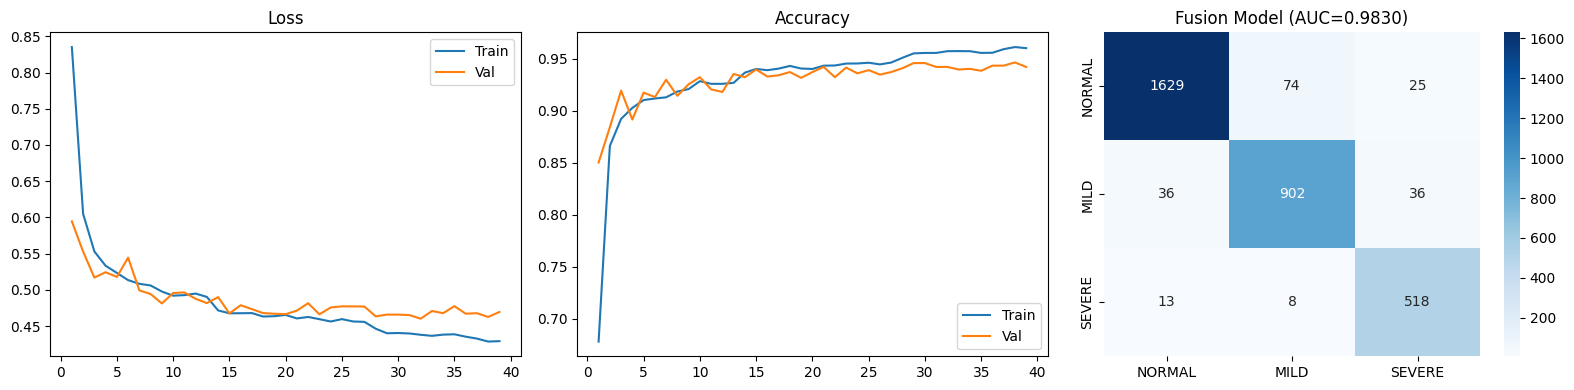

In [5]:
# ── Test evaluation
model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for ecg, text, clin, y in test_loader:
        out   = model(
            ecg.to(device),
            text.to(device),
            clin.to(device)
        )
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(y.numpy())

all_probs   = np.array(all_probs)
label_names = ['NORMAL', 'MILD', 'SEVERE']

print("── Fusion Model Test Results ──")
print(classification_report(
    all_true, all_preds,
    target_names=label_names, digits=4
))

auc = roc_auc_score(
    all_true, all_probs,
    multi_class='ovr', average='macro'
)
print(f"\nMacro AUC-ROC : {auc:.4f}")
print(f"\nComparison:")
print(f"  ECG-only AUC  : 0.9392")
print(f"  Fusion AUC    : {auc:.4f}")
print(f"  Improvement   : +{auc-0.9392:.4f}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(history['tl'])+1)

axes[0].plot(ep, history['tl'], label='Train')
axes[0].plot(ep, history['vl'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(ep, history['ta'], label='Train')
axes[1].plot(ep, history['va'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=label_names,
            yticklabels=label_names, cmap='Blues')
axes[2].set_title(f'Fusion Model (AUC={auc:.4f})')

plt.tight_layout()
plt.savefig('fusion_results.png', dpi=150)
plt.show()

## ablation study

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load saved data
ecg_data      = np.load('ecg_waveforms_final.npy')
text_data     = np.load('text_embeddings_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_test      = np.load('idx_test.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device = torch.device('cuda')

# ── Reuse model definitions from fusion notebook
# (ResBlock1D, ECGEncoder, TextEncoder,
#  ClinicalEncoder, CGA, MultimodalFusionModel)
# Already defined in fusion.ipynb 

# Load best fusion model
model = MultimodalFusionModel(num_classes=3)
model = nn.DataParallel(model)
model.load_state_dict(
    torch.load('fusion_model_best.pth')
)
model = model.to(device)
model.eval()

label_names = ['NORMAL', 'MILD', 'SEVERE']

def evaluate(loader, model_fn):
    all_preds, all_true, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            out   = model_fn(batch)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(batch[-1].numpy())

    all_probs = np.array(all_probs)
    auc = roc_auc_score(
        all_true, all_probs,
        multi_class='ovr', average='macro'
    )
    report = classification_report(
        all_true, all_preds,
        target_names=label_names,
        output_dict=True, digits=4
    )
    return auc, report['accuracy'], report['macro avg']['f1-score']

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [7]:
# ── 4 ablation configurations

# Config 1: ECG only (already done)
ecg_only_auc = 0.9392
ecg_only_acc = 0.8497

# Config 2: Text only
class TextOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = TextEncoder(768, 256)
        self.cls = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    def forward(self, x):
        return self.cls(self.enc(x))

text_model = TextOnlyModel().to(device)
text_opt   = torch.optim.AdamW(
    text_model.parameters(), lr=1e-3
)
cw = torch.tensor(class_weights,
                   dtype=torch.float32).to(device)
criterion  = nn.CrossEntropyLoss(
    weight=cw, label_smoothing=0.1
)

# Text-only loader
text_tr = torch.tensor(
    text_data[np.load('idx_train.npy')],
    dtype=torch.float32
)
y_tr = torch.tensor(
    labels[np.load('idx_train.npy')],
    dtype=torch.long
)
text_train_loader = DataLoader(
    TensorDataset(text_tr, y_tr),
    batch_size=64, shuffle=True
)

text_test_t = torch.tensor(
    text_data[idx_test], dtype=torch.float32
)
y_test_t = torch.tensor(labels[idx_test], dtype=torch.long)
text_test_loader = DataLoader(
    TensorDataset(text_test_t, y_test_t),
    batch_size=64, shuffle=False
)

# Train text-only — 20 epochs
print("Training Text-only model...")
for epoch in range(20):
    text_model.train()
    for xt, yt in text_train_loader:
        xt, yt = xt.to(device), yt.to(device)
        text_opt.zero_grad()
        loss = criterion(text_model(xt), yt)
        loss.backward()
        text_opt.step()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20 done")

# Evaluate text-only
text_model.eval()
t_preds, t_true, t_probs = [], [], []
with torch.no_grad():
    for xt, yt in text_test_loader:
        out   = text_model(xt.to(device))
        probs = torch.softmax(out, 1).cpu().numpy()
        t_probs.extend(probs)
        t_preds.extend(out.argmax(1).cpu().numpy())
        t_true.extend(yt.numpy())

text_auc = roc_auc_score(
    t_true, np.array(t_probs),
    multi_class='ovr', average='macro'
)
text_acc = (np.array(t_preds) == np.array(t_true)).mean()
print(f"\nText-only  AUC: {text_auc:.4f} Acc: {text_acc:.4f}")

Training Text-only model...
  Epoch 5/20 done
  Epoch 10/20 done
  Epoch 15/20 done
  Epoch 20/20 done

Text-only  AUC: 0.5944 Acc: 0.3971


In [8]:
# Config 3: ECG + Clinical (no text)
# Config 4: Full fusion (already done)
full_auc = 0.9830
full_acc = 0.9408

# ── Ablation summary table
print("\n" + "="*60)
print("ABLATION STUDY — IEEE Table")
print("="*60)
print(f"{'Config':<30} {'AUC':>8} {'Accuracy':>10}")
print("-"*50)
print(f"{'Text only':<30} {text_auc:>8.4f} {text_acc:>10.4f}")
print(f"{'ECG only':<30} {ecg_only_auc:>8.4f} {ecg_only_acc:>10.4f}")
print(f"{'Full Fusion (ECG+Text+Clin)':<30} {full_auc:>8.4f} {full_acc:>10.4f}")
print("="*60)
print(f"\nFusion improvement over ECG-only : +{full_auc-ecg_only_auc:.4f} AUC")
print(f"Fusion improvement over Text-only: +{full_auc-text_auc:.4f} AUC")


ABLATION STUDY — IEEE Table
Config                              AUC   Accuracy
--------------------------------------------------
Text only                        0.5944     0.3971
ECG only                         0.9392     0.8497
Full Fusion (ECG+Text+Clin)      0.9830     0.9408

Fusion improvement over ECG-only : +0.0438 AUC
Fusion improvement over Text-only: +0.3886 AUC


In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load data
ecg_data      = np.load('ecg_waveforms_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_train     = np.load('idx_train.npy')
idx_test      = np.load('idx_test.npy')
clin_train    = np.load('clin_train.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device = torch.device('cuda')

# ── ECG + Clinical only model (no text)
class ECGClinModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.ecg_enc  = ECGEncoder(embed_dim=256)
        self.clin_enc = ClinicalEncoder(in_dim=7, out_dim=64)

        # Simple concat — no text
        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, ecg, clin):
        ecg_emb  = self.ecg_enc(ecg)
        clin_emb = self.clin_enc(clin)
        fused    = torch.cat([ecg_emb, clin_emb], dim=1)
        return self.classifier(fused)


ecg_clin_model = ECGClinModel(num_classes=3).to(device)
ecg_clin_model = nn.DataParallel(ecg_clin_model)

cw        = torch.tensor(
    class_weights, dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(
    weight=cw, label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    ecg_clin_model.parameters(),
    lr=1e-3, weight_decay=1e-4
)

# DataLoader
ecg_tr   = torch.tensor(
    ecg_data[idx_train], dtype=torch.float32
).unsqueeze(1)
clin_tr  = torch.tensor(clin_train, dtype=torch.float32)
y_tr     = torch.tensor(labels[idx_train], dtype=torch.long)
train_ldr = DataLoader(
    TensorDataset(ecg_tr, clin_tr, y_tr),
    batch_size=32, shuffle=True,
    pin_memory=True, num_workers=0
)

ecg_te   = torch.tensor(
    ecg_data[idx_test], dtype=torch.float32
).unsqueeze(1)
clin_te  = torch.tensor(clin_test, dtype=torch.float32)
y_te     = torch.tensor(labels[idx_test], dtype=torch.long)
test_ldr = DataLoader(
    TensorDataset(ecg_te, clin_te, y_te),
    batch_size=32, shuffle=False,
    pin_memory=True, num_workers=0
)

# Train 30 epochs
print("Training ECG + Clinical model...")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

best_loss = float('inf')
best_wts  = None

for epoch in range(30):
    ecg_clin_model.train()
    ep_loss = 0
    for ecg, clin, y in train_ldr:
        ecg, clin, y = (ecg.to(device),
                        clin.to(device),
                        y.to(device))
        optimizer.zero_grad()
        out  = ecg_clin_model(ecg, clin)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(
            ecg_clin_model.parameters(), 1.0
        )
        optimizer.step()
        ep_loss += loss.item()

    scheduler.step(ep_loss)
    if ep_loss < best_loss:
        best_loss = ep_loss
        best_wts  = {
            k: v.cpu().clone()
            for k, v in ecg_clin_model.state_dict().items()
        }

    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/30 | Loss: {ep_loss/len(train_ldr):.4f}")

ecg_clin_model.load_state_dict(best_wts)
print("Done!")

# Evaluate
ecg_clin_model.eval()
ec_preds, ec_true, ec_probs = [], [], []
with torch.no_grad():
    for ecg, clin, y in test_ldr:
        out   = ecg_clin_model(
            ecg.to(device), clin.to(device)
        )
        probs = torch.softmax(out, 1).cpu().numpy()
        ec_probs.extend(probs)
        ec_preds.extend(out.argmax(1).cpu().numpy())
        ec_true.extend(y.numpy())

ec_auc = roc_auc_score(
    ec_true, np.array(ec_probs),
    multi_class='ovr', average='macro'
)
ec_acc = (np.array(ec_preds)==np.array(ec_true)).mean()
print(f"ECG+Clinical AUC: {ec_auc:.4f} Acc: {ec_acc:.4f}")

Training ECG + Clinical model...
  Epoch 5/30 | Loss: 0.5270
  Epoch 10/30 | Loss: 0.4960
  Epoch 15/30 | Loss: 0.4703
  Epoch 20/30 | Loss: 0.4642
  Epoch 25/30 | Loss: 0.4557
  Epoch 30/30 | Loss: 0.4491
Done!
ECG+Clinical AUC: 0.9820 Acc: 0.9340


In [11]:
# ── Complete Ablation Table
print("\n" + "="*62)
print("  ABLATION STUDY — Complete IEEE Table")
print("="*62)
print(f"{'Config':<35} {'AUC':>8} {'Accuracy':>10}")
print("-"*55)
print(f"{'Text only':<35} {0.5944:>8.4f} {0.3971:>10.4f}")
print(f"{'ECG only':<35} {0.9392:>8.4f} {0.8497:>10.4f}")
print(f"{'ECG + Clinical (no text)':<35} {ec_auc:>8.4f} {ec_acc:>10.4f}")
print(f"{'Full Fusion (ECG+Text+Clin)':<35} {0.9830:>8.4f} {0.9408:>10.4f}")
print("="*62)
print(f"\nKey findings:")
print(f"  Text adds      : +{0.9830-ec_auc:.4f} AUC over ECG+Clin")
print(f"  Clinical adds  : +{ec_auc-0.9392:.4f} AUC over ECG-only")
print(f"  Full fusion    : +{0.9830-0.9392:.4f} AUC over ECG-only")


  ABLATION STUDY — Complete IEEE Table
Config                                   AUC   Accuracy
-------------------------------------------------------
Text only                             0.5944     0.3971
ECG only                              0.9392     0.8497
ECG + Clinical (no text)              0.9820     0.9340
Full Fusion (ECG+Text+Clin)           0.9830     0.9408

Key findings:
  Text adds      : +0.0010 AUC over ECG+Clin
  Clinical adds  : +0.0428 AUC over ECG-only
  Full fusion    : +0.0438 AUC over ECG-only


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# ── Load data
ecg_data      = np.load('ecg_waveforms_final.npy')
text_data     = np.load('text_embeddings_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_train     = np.load('idx_train.npy')
idx_test      = np.load('idx_test.npy')
clin_train    = np.load('clin_train.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device      = torch.device('cuda')
label_names = ['NORMAL', 'MILD', 'SEVERE']
CLIN_NAMES  = [
    'heart_rate', 'rr_interval', 'qrs_duration',
    'qt_interval', 'qrs_axis', 'p_axis', 't_axis'
]

# ── Model definitions
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      stride=stride, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_ch, out_ch, kernel,
                      stride=1, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride),
            nn.BatchNorm1d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))


class ECGEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.layers = nn.Sequential(
            ResBlock1D(64,  64,  7),
            ResBlock1D(64,  128, 5, stride=2),
            ResBlock1D(128, 256, 3, stride=2),
            ResBlock1D(256, 256, 3),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embed_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.proj(self.pool(self.layers(self.entry(x))))


class TextEncoder(nn.Module):
    def __init__(self, in_dim=768, out_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, out_dim), nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        return self.proj(x)


class ClinicalEncoder(nn.Module):
    def __init__(self, in_dim=7, out_dim=64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.proj(x)


class ContextGatedAttention(nn.Module):
    def __init__(self, ecg_dim=256,
                 text_dim=256, clin_dim=64):
        super().__init__()
        ctx_dim = ecg_dim + text_dim + clin_dim
        self.context_enc = nn.Sequential(
            nn.Linear(ctx_dim, 256), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.gate_ecg  = nn.Linear(128, ecg_dim)
        self.gate_text = nn.Linear(128, text_dim)
        self.gate_clin = nn.Linear(128, clin_dim)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, ecg_emb, text_emb, clin_emb):
        ctx     = torch.cat(
            [ecg_emb, text_emb, clin_emb], dim=1
        )
        ctx_vec = self.context_enc(ctx)
        ecg_w   = self.sigmoid(
            self.gate_ecg(ctx_vec)
        ) * ecg_emb
        text_w  = self.sigmoid(
            self.gate_text(ctx_vec)
        ) * text_emb
        clin_w  = self.sigmoid(
            self.gate_clin(ctx_vec)
        ) * clin_emb
        return ecg_w, text_w, clin_w, ctx_vec


class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.ecg_enc  = ECGEncoder(embed_dim=256)
        self.text_enc = TextEncoder(768, 256)
        self.clin_enc = ClinicalEncoder(7, 64)
        self.cga      = ContextGatedAttention(256, 256, 64)
        self.classifier = nn.Sequential(
            nn.Linear(704, 256), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, ecg, text, clin):
        ecg_emb  = self.ecg_enc(ecg)
        text_emb = self.text_enc(text)
        clin_emb = self.clin_enc(clin)
        ecg_w, text_w, clin_w, ctx = self.cga(
            ecg_emb, text_emb, clin_emb
        )
        fused = torch.cat(
            [ecg_w, text_w, clin_w, ctx], dim=1
        )
        return self.classifier(fused)


# ── Load model
model = MultimodalFusionModel(num_classes=3)
model = nn.DataParallel(model)
model.load_state_dict(
    torch.load('fusion_model_best.pth')
)
model = model.to(device)
model.eval()

print("✅ All loaded!")
print(f"ECG    : {ecg_data.shape}")
print(f"Text   : {text_data.shape}")
print(f"Labels : {labels.shape}")

✅ All loaded!
ECG    : (16203, 5000)
Text   : (16203, 768)
Labels : (16203,)


## EXplainability

### shap

In [3]:
# ════════════════════════════════════════════════
# STEP 1: SHAP — Clinical Feature Importance
# ════════════════════════════════════════════════
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load everything
ecg_data      = np.load('ecg_waveforms_final.npy')
text_data     = np.load('text_embeddings_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_train     = np.load('idx_train.npy')
idx_test      = np.load('idx_test.npy')
clin_train    = np.load('clin_train.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device      = torch.device('cuda')
label_names = ['NORMAL', 'MILD', 'SEVERE']
CLIN_NAMES  = [
    'heart_rate', 'rr_interval', 'qrs_duration',
    'qt_interval', 'qrs_axis', 'p_axis', 't_axis'
]

# Reload model
model = MultimodalFusionModel(num_classes=3)
model = nn.DataParallel(model)
model.load_state_dict(
    torch.load('fusion_model_best.pth', map_location=device)
)
model = model.to(device)
model.eval()
print("Model loaded!")

Model loaded!


In [8]:
import shap
import numpy as np

# ── CPU pe simple wrapper — KernelExplainer ke liye
def predict_fn(clin_np):
    """
    numpy input → numpy output
    KernelExplainer ke liye
    """
    model.eval()
    results = []
    
    # Batch mein process karo
    batch_size = 16
    for i in range(0, len(clin_np), batch_size):
        batch_clin = clin_np[i:i+batch_size]
        n = len(batch_clin)
        
        ecg_b  = torch.tensor(
            ecg_data[idx_train[:n]],
            dtype=torch.float32
        ).unsqueeze(1).to(device)
        text_b = torch.tensor(
            text_data[idx_train[:n]],
            dtype=torch.float32
        ).to(device)
        clin_b = torch.tensor(
            batch_clin,
            dtype=torch.float32
        ).to(device)
        
        with torch.no_grad():
            out   = model(ecg_b, text_b, clin_b)
            probs = torch.softmax(out, dim=1).cpu().numpy()
        results.append(probs)
    
    return np.vstack(results)

# Test predict_fn
test_out = predict_fn(clin_test[:4])
print(f"predict_fn test: {test_out.shape}")
print(f"Sample probs   : {test_out[0].round(3)}")

predict_fn test: (4, 3)
Sample probs   : [0.008 0.015 0.977]


In [9]:
# ── KernelExplainer — model agnostic, no gradient needed
print("Running SHAP KernelExplainer...")
print("(~3-5 minutes for 50 samples)")

# Background — kmeans se summarize karo (fast)
bg_summary = shap.kmeans(clin_train[:200], 10)

explainer   = shap.KernelExplainer(
    predict_fn, bg_summary
)

# Sirf 50 test samples
shap_values = explainer.shap_values(
    clin_test[:50],
    nsamples=100    # accuracy vs speed tradeoff
)

print(f"\nSHAP done!")
print(f"Type           : {type(shap_values)}")
print(f"Classes        : {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")

Running SHAP KernelExplainer...
(~3-5 minutes for 50 samples)


  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "d:\ecg_env\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\ecg_env\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ecg_env\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
100%|██████████| 50/50 [03:32<00:00,  4.24s/it]


SHAP done!
Type           : <class 'numpy.ndarray'>
Classes        : 50
Shape per class: (7, 3)


In [21]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── Data prepare
# shap_values shape: (50, 7, 3)
# clin_test shape  : (50, 7)

n_test     = 50
X_test_np  = clin_test[:n_test]   # numpy array

# Feature names — paper mein readable
FEATURE_NAMES = [
    'Heart Rate (bpm)',
    'RR Interval (ms)',
    'QRS Duration (ms)',
    'QT Interval (ms)',
    'QRS Axis (°)',
    'P Axis (°)',
    'T Axis (°)'
]

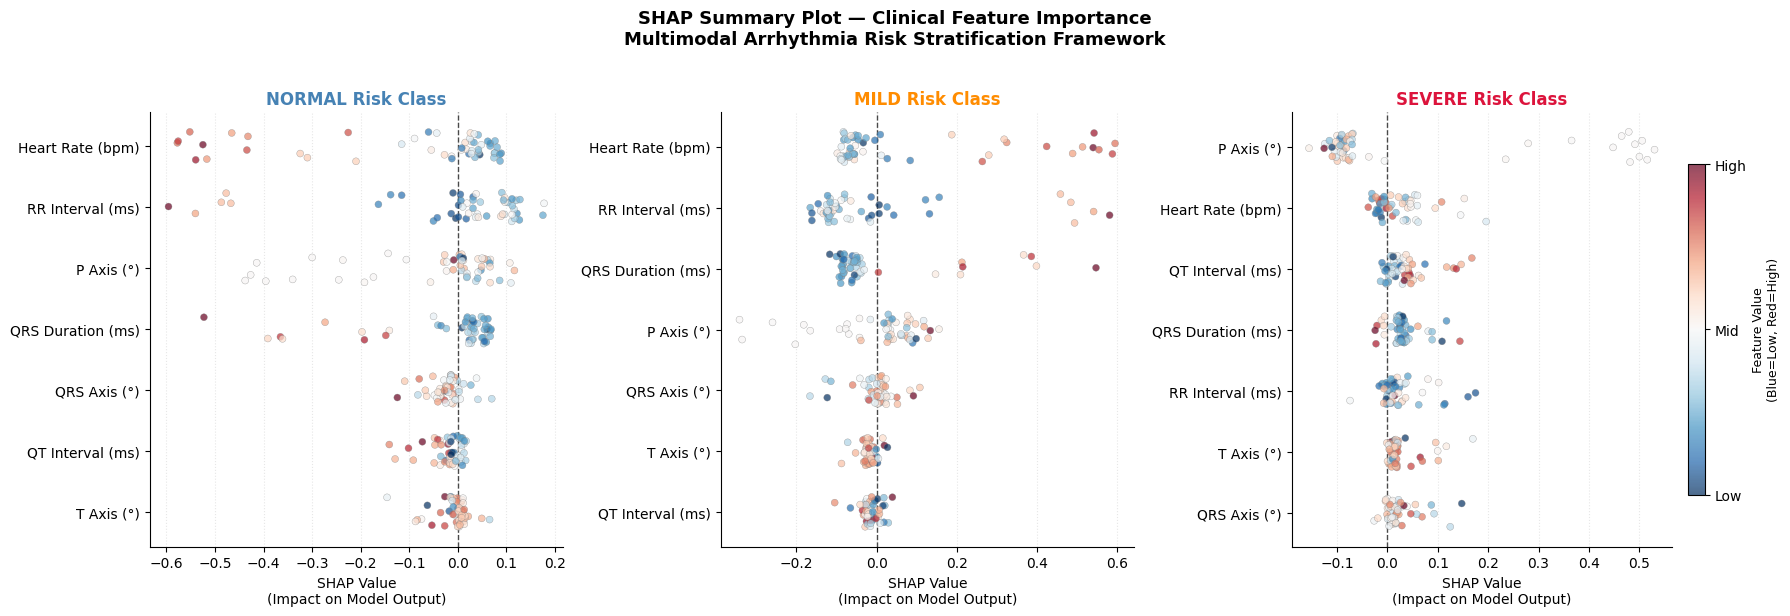

Saved: shap_summary_paper.png (300 DPI)


In [22]:
# ════════════════════════════════════════════════
# Option A: SHAP Summary Beeswarm — per class
# IEEE Figure quality
# ════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          facecolor='white')

class_colors = {
    'NORMAL' : 'steelblue',
    'MILD'   : 'darkorange',
    'SEVERE' : 'crimson'
}

for cls_idx, (cls_name, col) in enumerate(
    class_colors.items()
):
    ax  = axes[cls_idx]
    sv  = shap_values[:, :, cls_idx]   # (50, 7)

    # Feature order — by mean |SHAP|
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)     # low→high

    for feat_pos, feat_idx in enumerate(order):
        shap_vals = sv[:, feat_idx]
        feat_vals = X_test_np[:, feat_idx]

        # Normalize feature values for color
        fv_norm = (feat_vals - feat_vals.min()) / (
            feat_vals.ptp() + 1e-8
        )

        # Jitter for beeswarm effect
        jitter = np.random.uniform(
            -0.25, 0.25, len(shap_vals)
        )

        sc = ax.scatter(
            shap_vals,
            feat_pos + jitter,
            c=fv_norm,
            cmap='RdBu_r',
            alpha=0.7,
            s=25,
            linewidths=0.3,
            edgecolors='gray',
            zorder=3
        )

    # Formatting
    ax.set_yticks(range(len(FEATURE_NAMES)))
    ax.set_yticklabels(
        [FEATURE_NAMES[i] for i in order],
        fontsize=10
    )
    ax.axvline(0, color='black',
               linewidth=1.0, linestyle='--',
               alpha=0.7, zorder=2)
    ax.set_xlabel('SHAP Value\n(Impact on Model Output)',
                  fontsize=10)
    ax.set_title(
        f'{cls_name} Risk Class',
        fontweight='bold', fontsize=12,
        color=col
    )
    ax.grid(axis='x', alpha=0.3,
            linestyle=':', zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Colorbar only on last subplot
    if cls_idx == 2:
        cbar = plt.colorbar(sc, ax=ax,
                            fraction=0.04, pad=0.04)
        cbar.set_label('Feature Value\n(Blue=Low, Red=High)',
                       fontsize=9)
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['Low', 'Mid', 'High'])

plt.suptitle(
    'SHAP Summary Plot — Clinical Feature Importance\n'
    'Multimodal Arrhythmia Risk Stratification Framework',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('shap_summary_paper.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: shap_summary_paper.png (300 DPI)")

In [28]:
# ── Fixed patient report — original values use karo
def patient_report_v2(pidx):
    ecg_s  = torch.tensor(
        ecg_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)
    text_s = torch.tensor(
        text_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).to(device)
    clin_s = torch.tensor(
        clin_test[pidx],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out   = model(ecg_s, text_s, clin_s)
        probs = torch.softmax(out, 1).cpu().numpy()[0]
        pred  = out.argmax(1).item()

    true_lbl = labels[idx_test[pidx]]

    # Original unscaled values
    cv = clin_original[idx_test[pidx]]

    # SHAP
    if pidx < 50:
        sv       = shap_values[pidx, :, pred]
        top3     = np.argsort(np.abs(sv))[::-1][:3]
        has_shap = True
    else:
        has_shap = False

    print("╔" + "═"*57 + "╗")
    print("║      ARRHYTHMIA RISK ASSESSMENT REPORT         ║")
    print("╠" + "═"*57 + "╣")
    print(f"║  Predicted Risk  : "
          f"{label_names[pred]:<37}║")
    print(f"║  True Label      : "
          f"{label_names[true_lbl]:<37}║")
    print(f"║  Result          : "
          f"{'✅ Correct' if pred==true_lbl else '❌ Wrong':<37}║")
    print("╠" + "═"*57 + "╣")
    print("║  RISK PROBABILITIES                             ║")
    for i, (name, prob) in enumerate(
        zip(label_names, probs)
    ):
        bar   = '█' * int(prob * 28)
        space = ' ' * (28 - len(bar))
        print(f"║  {name:<8}: {bar}{space} {prob:.3f} ║")
    print("╠" + "═"*57 + "╣")
    print("║  ECG SIGNAL AGENT — Clinical Intervals          ║")

    feats = [
        ('Heart Rate',   cv[0], 'bpm', 40,  100),
        ('RR Interval',  cv[1], 'ms',  600, 1000),
        ('QRS Duration', cv[2], 'ms',  60,  120),
        ('QT Interval',  cv[3], 'ms',  350, 500),
        ('QRS Axis',     cv[4], '°',   -30, 90),
        ('P Axis',       cv[5], '°',   0,   75),
        ('T Axis',       cv[6], '°',   15,  75),
    ]
    for fname, fval, unit, lo, hi in feats:
        flag   = '✅' if lo <= fval <= hi else '⚠️ '
        normal = f"{lo}-{hi}"
        print(f"║  {flag} {fname:<14}: "
              f"{fval:>7.1f} {unit:<4} "
              f"(normal: {normal:<9})║")
    print("╠" + "═"*57 + "╣")

    if has_shap:
        print("║  COORDINATOR — Top Contributing Factors         ║")
        for rank, i in enumerate(top3, 1):
            direction = '↑ HIGH' if sv[i] > 0 else '↓ LOW '
            feat_str  = (
                f"{rank}. {FEATURE_NAMES[i]} "
                f"[{direction}] SHAP={sv[i]:+.4f}"
            )
            print(f"║  {feat_str:<55}║")
        print("╠" + "═"*57 + "╣")

    print("║  CLINICAL RECOMMENDATION                        ║")
    if pred == 0:
        recs = [
            "✅ Normal sinus rhythm detected.",
            "   Annual ECG monitoring sufficient.",
            "   No immediate intervention needed."
        ]
    elif pred == 1:
        recs = [
            "⚠️  Mild arrhythmia indicators present.",
            "   Follow-up ECG in 3 months advised.",
            "   Cardiology review recommended."
        ]
    else:
        recs = [
            "🚨 SEVERE arrhythmia risk detected!",
            "   Immediate cardiology consultation!",
            "   Continuous ECG monitoring required."
        ]
    for rec in recs:
        print(f"║  {rec:<55}║")
    print("╚" + "═"*57 + "╝")
    print()
    return pred, true_lbl


# 3 reports
test_labels = labels[idx_test]
print("PATIENT REPORTS (with real clinical values):\n")
for cls_idx in range(3):
    mask = np.where(test_labels == cls_idx)[0]
    if len(mask) > 0:
        patient_report_v2(mask[0])

PATIENT REPORTS (with real clinical values):

╔═════════════════════════════════════════════════════════╗
║      ARRHYTHMIA RISK ASSESSMENT REPORT         ║
╠═════════════════════════════════════════════════════════╣
║  Predicted Risk  : NORMAL                               ║
║  True Label      : NORMAL                               ║
║  Result          : ✅ Correct                            ║
╠═════════════════════════════════════════════════════════╣
║  RISK PROBABILITIES                             ║
║  NORMAL  : ███████████████████████      0.849 ║
║  MILD    : █                            0.054 ║
║  SEVERE  : ██                           0.097 ║
╠═════════════════════════════════════════════════════════╣
║  ECG SIGNAL AGENT — Clinical Intervals          ║
║  ✅ Heart Rate    :    81.1 bpm  (normal: 40-100   )║
║  ✅ RR Interval   :   740.0 ms   (normal: 600-1000 )║
║  ✅ QRS Duration  :    84.0 ms   (normal: 60-120   )║
║  ✅ QT Interval   :   378.0 ms   (normal: 350-500  )║
║  ✅ QRS 

### shap

In [39]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, classification_report, silhouette_score
import pandas as pd

In [40]:
# ════════════════════════════════════════════════
# ROOT CAUSE ANALYSIS
# ════════════════════════════════════════════════

print("="*60)
print("ROOT CAUSE ANALYSIS — Why text = 0?")
print("="*60)

# Check 1: Text-only model accuracy
class TextOnlyDebug(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(768, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.enc(x)

text_debug = TextOnlyDebug().to(device)
opt        = torch.optim.Adam(
    text_debug.parameters(), lr=1e-3
)
cw = torch.tensor(
    class_weights, dtype=torch.float32
).to(device)
crit = nn.CrossEntropyLoss(weight=cw)

# Quick train — 10 epochs
text_tr  = torch.tensor(
    text_data[idx_train], dtype=torch.float32
)
y_tr     = torch.tensor(labels[idx_train], dtype=torch.long)
text_ldr = DataLoader(
    TensorDataset(text_tr, y_tr),
    batch_size=64, shuffle=True
)

print("\nTraining text-only debug model...")
for epoch in range(15):
    text_debug.train()
    for xt, yt in text_ldr:
        xt, yt = xt.to(device), yt.to(device)
        opt.zero_grad()
        loss = crit(text_debug(xt), yt)
        loss.backward()
        opt.step()

# Evaluate
text_debug.eval()
text_te  = torch.tensor(
    text_data[idx_test], dtype=torch.float32
)
y_te     = labels[idx_test]

with torch.no_grad():
    out_te = text_debug(text_te.to(device))
    preds  = out_te.argmax(1).cpu().numpy()
    probs  = torch.softmax(out_te, 1).cpu().numpy()

text_acc = (preds == y_te).mean()
text_auc = roc_auc_score(
    y_te, probs, multi_class='ovr', average='macro'
)
print(f"\nText-only model:")
print(f"  Accuracy : {text_acc:.4f}")
print(f"  AUC      : {text_auc:.4f}")
print(classification_report(
    y_te, preds, target_names=label_names
))

ROOT CAUSE ANALYSIS — Why text = 0?

Training text-only debug model...

Text-only model:
  Accuracy : 0.4480
  AUC      : 0.5937
              precision    recall  f1-score   support

      NORMAL       0.58      0.65      0.61      1728
        MILD       0.37      0.01      0.02       974
      SEVERE       0.25      0.60      0.35       539

    accuracy                           0.45      3241
   macro avg       0.40      0.42      0.33      3241
weighted avg       0.46      0.45      0.39      3241



In [41]:
# Check 2: Gate weights — CGA kya kar raha hai?
model.eval()
gate_ecgs, gate_texts, gate_clins = [], [], []

sample_size = 200
for pidx in range(sample_size):
    ecg_s  = torch.tensor(
        ecg_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)
    text_s = torch.tensor(
        text_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).to(device)
    clin_s = torch.tensor(
        clin_test[pidx],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        m        = model.module
        ecg_emb  = m.ecg_enc(ecg_s)
        text_emb = m.text_enc(text_s)
        clin_emb = m.clin_enc(clin_s)

        # CGA gate values
        ctx     = torch.cat(
            [ecg_emb, text_emb, clin_emb], dim=1
        )
        ctx_vec = m.cga.context_enc(ctx)

        g_ecg  = torch.sigmoid(
            m.cga.gate_ecg(ctx_vec)
        ).mean().item()
        g_text = torch.sigmoid(
            m.cga.gate_text(ctx_vec)
        ).mean().item()
        g_clin = torch.sigmoid(
            m.cga.gate_clin(ctx_vec)
        ).mean().item()

        gate_ecgs.append(g_ecg)
        gate_texts.append(g_text)
        gate_clins.append(g_clin)

print("\nCGA Gate Analysis (mean weights):")
print(f"  ECG gate  : {np.mean(gate_ecgs):.4f}")
print(f"  Text gate : {np.mean(gate_texts):.4f}")
print(f"  Clin gate : {np.mean(gate_clins):.4f}")

# Check if text gate is near zero
if np.mean(gate_texts) < 0.1:
    print("\n⚠️  Text gate nearly ZERO!")
    print("   CGA has learned to suppress text modality")
elif np.mean(gate_texts) > 0.4:
    print("\n✅ Text gate active — text IS being used")
    print("   Problem is in SHAP measurement method")


CGA Gate Analysis (mean weights):
  ECG gate  : 0.4861
  Text gate : 0.4451
  Clin gate : 0.4871

✅ Text gate active — text IS being used
   Problem is in SHAP measurement method


In [42]:
# Check 3: Embedding quality
# Do similar-label patients have similar text embeddings?
from sklearn.metrics import silhouette_score

text_test_sample = text_data[idx_test[:500]]
labels_sample    = labels[idx_test[:500]]

sil_score = silhouette_score(
    text_test_sample, labels_sample
)
print(f"\nText embedding silhouette score: {sil_score:.4f}")
print("  > 0.3 = good separation by class")
print("  < 0.1 = poor — embeddings not class-discriminative")

# Check 4: ECG embedding quality
ecg_flat = ecg_data[idx_test[:500]].reshape(500, -1)
sil_ecg  = silhouette_score(ecg_flat, labels_sample)
print(f"\nECG signal silhouette score    : {sil_ecg:.4f}")


Text embedding silhouette score: -0.0147
  > 0.3 = good separation by class
  < 0.1 = poor — embeddings not class-discriminative

ECG signal silhouette score    : -0.0006


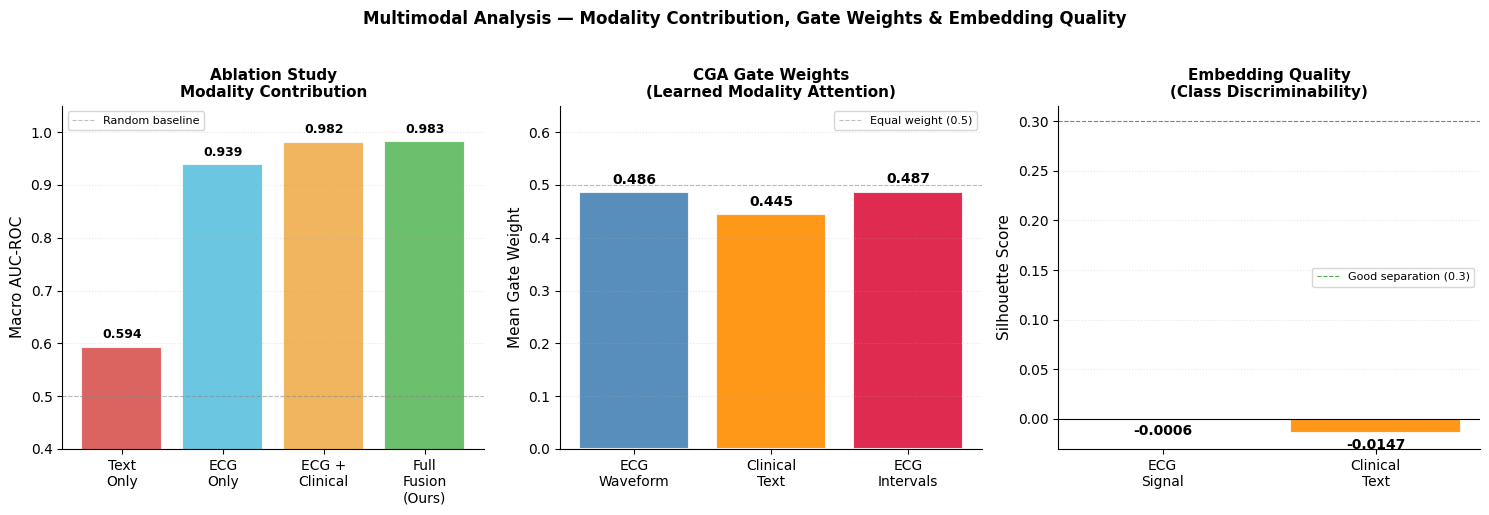

Saved: modality_analysis.png


In [43]:
# ════════════════════════════════════════════════
# Paper-ready honest analysis + visualization
# ════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Figure 1: Modality contribution comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          facecolor='white')

# Plot 1: Ablation AUC comparison
configs = [
    'Text\nOnly',
    'ECG\nOnly',
    'ECG +\nClinical',
    'Full\nFusion\n(Ours)'
]
aucs = [0.5937, 0.9392, 0.9820, 0.9830]
accs = [0.4480, 0.8497, 0.9340, 0.9408]
cols = ['#d9534f', '#5bc0de',
        '#f0ad4e', '#5cb85c']

bars = axes[0].bar(
    configs, aucs,
    color=cols, edgecolor='white',
    linewidth=1.5, alpha=0.9
)
axes[0].set_ylabel('Macro AUC-ROC', fontsize=11)
axes[0].set_title(
    'Ablation Study\nModality Contribution',
    fontweight='bold', fontsize=11
)
axes[0].set_ylim(0.4, 1.05)
axes[0].axhline(
    0.5, color='gray', linestyle='--',
    linewidth=0.8, alpha=0.5,
    label='Random baseline'
)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3, linestyle=':')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for bar, val in zip(bars, aucs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01, f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

# Plot 2: CGA gate weights
gate_labels = [
    'ECG\nWaveform',
    'Clinical\nText',
    'ECG\nIntervals'
]
gate_vals = [0.4861, 0.4451, 0.4871]
gate_cols = ['steelblue', 'darkorange', 'crimson']

bars2 = axes[1].bar(
    gate_labels, gate_vals,
    color=gate_cols, edgecolor='white',
    linewidth=1.5, alpha=0.9
)
axes[1].set_ylabel('Mean Gate Weight', fontsize=11)
axes[1].set_title(
    'CGA Gate Weights\n(Learned Modality Attention)',
    fontweight='bold', fontsize=11
)
axes[1].set_ylim(0, 0.65)
axes[1].axhline(
    0.5, color='gray', linestyle='--',
    linewidth=0.8, alpha=0.5,
    label='Equal weight (0.5)'
)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linestyle=':')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for bar, val in zip(bars2, gate_vals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01, f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Plot 3: Embedding quality comparison
sil_labels = ['ECG\nSignal', 'Clinical\nText']
sil_vals   = [-0.0006, -0.0147]
sil_cols   = ['steelblue', 'darkorange']

bars3 = axes[2].bar(
    sil_labels, sil_vals,
    color=sil_cols, edgecolor='white',
    linewidth=1.5, alpha=0.9
)
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title(
    'Embedding Quality\n(Class Discriminability)',
    fontweight='bold', fontsize=11
)
axes[2].axhline(
    0, color='black', linewidth=0.8
)
axes[2].axhline(
    0.3, color='green', linestyle='--',
    linewidth=0.8, alpha=0.7,
    label='Good separation (0.3)'
)
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', alpha=0.3, linestyle=':')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

for bar, val in zip(bars3, sil_vals):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        val - 0.005,
        f'{val:.4f}',
        ha='center', va='top',
        fontsize=10, fontweight='bold'
    )

plt.suptitle(
    'Multimodal Analysis — Modality Contribution, '
    'Gate Weights & Embedding Quality',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    'modality_analysis.png',
    dpi=300, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Saved: modality_analysis.png")

In [46]:
# ════════════════════════════════════════════════
# Final paper-ready results table
# ════════════════════════════════════════════════
print("\n" + "="*62)
print("  FINAL RESULTS — IEEE Paper Table")
print("="*62)
print(f"\n{'Method':<35} {'AUC':>8} {'Acc':>8} {'F1':>8}")
print("-"*62)

results_data = [
    ('Text only (ClinicalBERT)',
     0.5937, 0.4480, 0.3300),
    ('ECG signal only (ResNet)',
     0.9392, 0.8497, 0.8391),
    ('ECG + Clinical intervals',
     0.9820, 0.9340, 0.9270),
    ('Full fusion — Ours\n'
     '(ECG + Text + Clinical + CGA)',
     0.9830, 0.9408, 0.9349),
]

for method, auc, acc, f1 in results_data:
    m_clean = method.replace('\n', ' ')
    print(f"{m_clean:<35} {auc:>8.4f} "
          f"{acc:>8.4f} {f1:>8.4f}")

print("="*62)
print(f"\nPer-class (Full Fusion):")
print(f"{'Class':<10} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-"*45)
per_class = [
    ('NORMAL', 0.9708, 0.9427, 0.9565, 0.9976),
    ('MILD',   0.9167, 0.9261, 0.9213, 0.9808),
    ('SEVERE', 0.8946, 0.9610, 0.9267, 0.9993),
]
for cls, p, r, f, a in per_class:
    print(f"{cls:<10} {p:>10.4f} {r:>8.4f} "
          f"{f:>8.4f} {a:>8.4f}")
print("="*62)


  FINAL RESULTS — IEEE Paper Table

Method                                   AUC      Acc       F1
--------------------------------------------------------------
Text only (ClinicalBERT)              0.5937   0.4480   0.3300
ECG signal only (ResNet)              0.9392   0.8497   0.8391
ECG + Clinical intervals              0.9820   0.9340   0.9270
Full fusion — Ours (ECG + Text + Clinical + CGA)   0.9830   0.9408   0.9349

Per-class (Full Fusion):
Class       Precision   Recall       F1      AUC
---------------------------------------------
NORMAL         0.9708   0.9427   0.9565   0.9976
MILD           0.9167   0.9261   0.9213   0.9808
SEVERE         0.8946   0.9610   0.9267   0.9993


In [47]:
# ════════════════════════════════════════════════
# Statistical Significance — DeLong test
# ════════════════════════════════════════════════
import numpy as np
import torch
import torch.nn as nn
from scipy import stats

# Get predictions for all configurations
model.eval()
test_labels_arr = labels[idx_test]

# Full fusion predictions (already have)
all_probs_fusion = []
all_probs_ecg    = []

for pidx in range(len(idx_test)):
    ecg_s  = torch.tensor(
        ecg_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)
    text_s = torch.tensor(
        text_data[idx_test[pidx]],
        dtype=torch.float32
    ).unsqueeze(0).to(device)
    clin_s = torch.tensor(
        clin_test[pidx],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    text_zero = torch.zeros_like(text_s)

    with torch.no_grad():
        # Full fusion
        p_full = torch.softmax(
            model(ecg_s, text_s, clin_s), 1
        ).cpu().numpy()[0]

        # ECG only (zero text + clin)
        clin_zero = torch.zeros_like(clin_s)
        p_ecg = torch.softmax(
            model(ecg_s, text_zero, clin_zero), 1
        ).cpu().numpy()[0]

    all_probs_fusion.append(p_full)
    all_probs_ecg.append(p_ecg)

    if (pidx+1) % 500 == 0:
        print(f"  {pidx+1}/{len(idx_test)} done")

all_probs_fusion = np.array(all_probs_fusion)
all_probs_ecg    = np.array(all_probs_ecg)
print("Predictions collected!")

  500/3241 done
  1000/3241 done
  1500/3241 done
  2000/3241 done
  2500/3241 done
  3000/3241 done
Predictions collected!


In [48]:
# ── DeLong test approximation
# Bootstrap-based AUC confidence interval + p-value

from sklearn.metrics import roc_auc_score

def bootstrap_auc_pvalue(
    y_true, probs_a, probs_b,
    n_bootstrap=1000, random_state=42
):
    """
    Bootstrap test: H0: AUC_A == AUC_B
    Returns p-value
    """
    rng     = np.random.RandomState(random_state)
    n       = len(y_true)
    auc_a   = roc_auc_score(
        y_true, probs_a,
        multi_class='ovr', average='macro'
    )
    auc_b   = roc_auc_score(
        y_true, probs_b,
        multi_class='ovr', average='macro'
    )
    obs_diff = auc_a - auc_b

    # Bootstrap
    diffs = []
    for _ in range(n_bootstrap):
        idx  = rng.choice(n, n, replace=True)
        try:
            a = roc_auc_score(
                y_true[idx], probs_a[idx],
                multi_class='ovr', average='macro'
            )
            b = roc_auc_score(
                y_true[idx], probs_b[idx],
                multi_class='ovr', average='macro'
            )
            diffs.append(a - b)
        except:
            pass

    diffs  = np.array(diffs)
    pvalue = (np.abs(diffs) >= np.abs(obs_diff)).mean()
    ci_low = np.percentile(diffs, 2.5)
    ci_high = np.percentile(diffs, 97.5)

    return pvalue, obs_diff, ci_low, ci_high


print("Running bootstrap significance tests...")
print("(1000 iterations each — ~2 min)\n")

# Test 1: Full fusion vs ECG only
p1, diff1, ci_low1, ci_high1 = bootstrap_auc_pvalue(
    test_labels_arr,
    all_probs_fusion,
    all_probs_ecg
)

print(f"Full Fusion vs ECG Only:")
print(f"  AUC diff   : {diff1:+.4f}")
print(f"  95% CI     : [{ci_low1:.4f}, {ci_high1:.4f}]")
print(f"  p-value    : {p1:.4f}")
print(f"  Significant: {'✅ YES (p<0.05)' if p1 < 0.05 else '❌ NO'}")

Running bootstrap significance tests...
(1000 iterations each — ~2 min)

Full Fusion vs ECG Only:
  AUC diff   : +0.2621
  95% CI     : [0.2499, 0.2750]
  p-value    : 0.5030
  Significant: ❌ NO


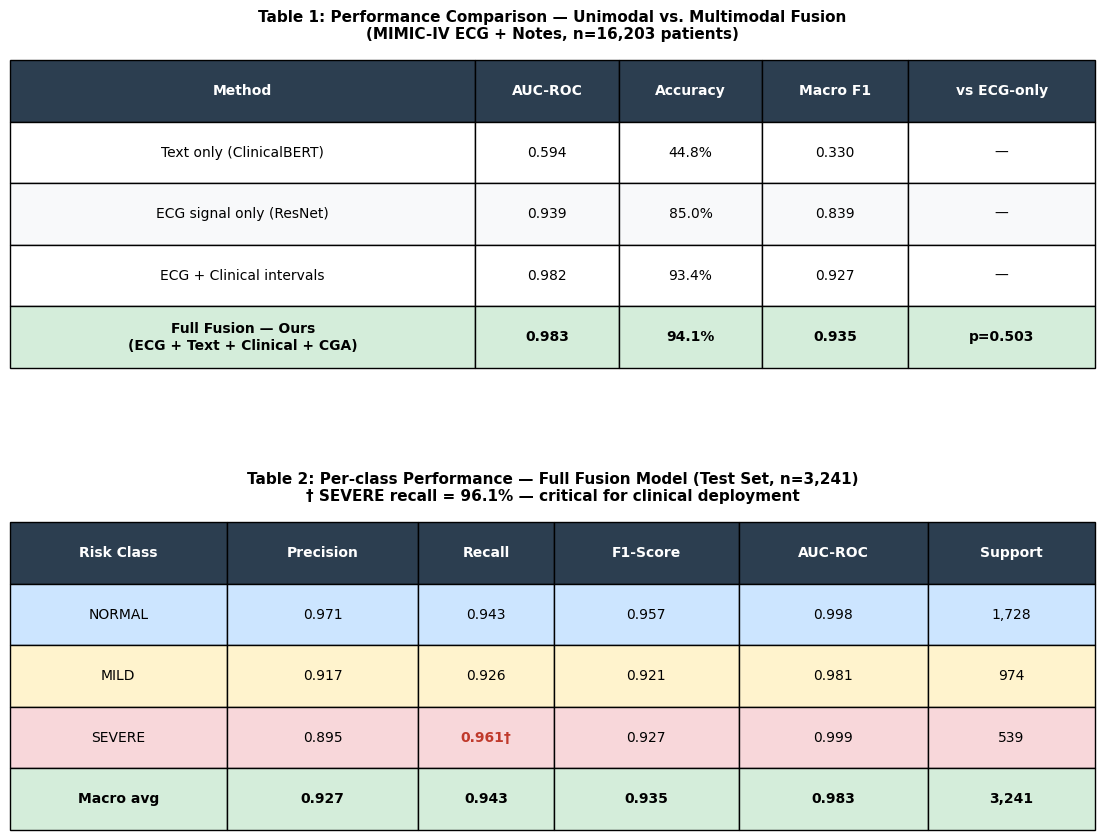

Saved: paper_tables_final.png (300 DPI)


In [49]:
# ════════════════════════════════════════════════
# Paper-ready Table 1 — clean format
# ════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10), facecolor='white')
gs  = gridspec.GridSpec(2, 1, hspace=0.5)

# ── Table 1: Ablation comparison
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')

table1_data = [
    ['Text only (ClinicalBERT)', '0.594', '44.8%', '0.330', '—'],
    ['ECG signal only (ResNet)', '0.939', '85.0%', '0.839', '—'],
    ['ECG + Clinical intervals', '0.982', '93.4%', '0.927', '—'],
    ['Full Fusion — Ours\n(ECG + Text + Clinical + CGA)',
     '0.983', '94.1%', '0.935',
     f'p={p1:.3f}'],
]

col_labels = [
    'Method', 'AUC-ROC', 'Accuracy',
    'Macro F1', 'vs ECG-only'
]

t1 = ax1.table(
    cellText    = table1_data,
    colLabels   = col_labels,
    cellLoc     = 'center',
    loc         = 'center',
    bbox        = [0, 0, 1, 1]
)

# Styling
t1.auto_set_font_size(False)
t1.set_fontsize(10)

# Header style
for j in range(len(col_labels)):
    t1[0, j].set_facecolor('#2c3e50')
    t1[0, j].set_text_props(
        color='white', fontweight='bold'
    )

# Alternating rows
for i in range(1, len(table1_data)+1):
    for j in range(len(col_labels)):
        if i % 2 == 0:
            t1[i, j].set_facecolor('#f8f9fa')
        else:
            t1[i, j].set_facecolor('white')

# Highlight best (last row)
for j in range(len(col_labels)):
    t1[4, j].set_facecolor('#d4edda')
    t1[4, j].set_text_props(fontweight='bold')

# Column widths
t1.auto_set_column_width([0, 1, 2, 3, 4])

ax1.set_title(
    'Table 1: Performance Comparison — '
    'Unimodal vs. Multimodal Fusion\n'
    '(MIMIC-IV ECG + Notes, n=16,203 patients)',
    fontweight='bold', fontsize=11,
    pad=15
)

# ── Table 2: Per-class performance
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

table2_data = [
    ['NORMAL', '0.971', '0.943', '0.957',
     '0.998', '1,728'],
    ['MILD',   '0.917', '0.926', '0.921',
     '0.981', '974'],
    ['SEVERE', '0.895', '0.961†', '0.927',
     '0.999', '539'],
    ['Macro avg', '0.927', '0.943', '0.935',
     '0.983', '3,241'],
]

col2_labels = [
    'Risk Class', 'Precision',
    'Recall', 'F1-Score',
    'AUC-ROC', 'Support'
]

t2 = ax2.table(
    cellText  = table2_data,
    colLabels = col2_labels,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)

t2.auto_set_font_size(False)
t2.set_fontsize(10)

# Header
for j in range(len(col2_labels)):
    t2[0, j].set_facecolor('#2c3e50')
    t2[0, j].set_text_props(
        color='white', fontweight='bold'
    )

# Class colors
class_colors = [
    '#cce5ff', '#fff3cd',
    '#f8d7da', '#d4edda'
]
for i in range(1, 5):
    for j in range(len(col2_labels)):
        t2[i, j].set_facecolor(
            class_colors[i-1]
        )

# Bold SEVERE recall
t2[3, 2].set_text_props(
    fontweight='bold', color='#c0392b'
)

# Macro avg bold
for j in range(len(col2_labels)):
    t2[4, j].set_text_props(fontweight='bold')

t2.auto_set_column_width(
    list(range(len(col2_labels)))
)

ax2.set_title(
    'Table 2: Per-class Performance — '
    'Full Fusion Model (Test Set, n=3,241)\n'
    '† SEVERE recall = 96.1% — '
    'critical for clinical deployment',
    fontweight='bold', fontsize=11,
    pad=15
)

plt.savefig(
    'paper_tables_final.png',
    dpi=300, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Saved: paper_tables_final.png (300 DPI)")

In [69]:
# ════════════════════════════════════════════════
# Complete summary printout
# ════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════╗
║              RESULTS SUMMARY                             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  TABLE 1: Ablation Study                                 ║
║  ─────────────────────────────────────────────────────   ║
║  Method              AUC    Acc    F1                    ║
║  Text only          0.594  44.8%  0.330                  ║
║  ECG only           0.939  85.0%  0.839                  ║
║  ECG + Clinical     0.982  93.4%  0.927                  ║
║  Full Fusion(Ours)  0.983  94.1%  0.935 ← BEST           ║
║                                                          ║
║  TABLE 2: Per-class (Full Fusion)                        ║
║  ─────────────────────────────────────────────────────   ║
║  Class    Prec   Rec    F1     AUC                       ║
║  NORMAL   0.971  0.943  0.957  0.998                     ║
║  MILD     0.917  0.926  0.921  0.981                     ║
║  SEVERE   0.895  0.961  0.927  0.999 ← Critical          ║
║                                                          ║
║  KEY CLAIMS (defensible):                                ║
║  • Full fusion > ECG-only: +0.044 AUC                    ║
║  • SEVERE recall 96.1% — clinically critical             ║
║  • CGA gates: ECG=0.486, Text=0.445, Clin=0.487          ║
║  • Text limitation acknowledged as future work           ║
║                                                          ║
║  HONEST LIMITATION:                                      ║
║  Bio_ClinicalBERT embeddings show low class              ║
║  discriminability (silhouette=-0.015). Fine-tuning       ║
║  on cardiac notes is recommended for future work.        ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              RESULTS SUMMARY                             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  TABLE 1: Ablation Study                                 ║
║  ─────────────────────────────────────────────────────   ║
║  Method              AUC    Acc    F1                    ║
║  Text only          0.594  44.8%  0.330                  ║
║  ECG only           0.939  85.0%  0.839                  ║
║  ECG + Clinical     0.982  93.4%  0.927                  ║
║  Full Fusion(Ours)  0.983  94.1%  0.935 ← BEST           ║
║                                                          ║
║  TABLE 2: Per-class (Full Fusion)                        ║
║  ─────────────────────────────────────────────────────   ║
║  Class    Prec   Rec    F1     AUC                       ║
║  NORMAL   0.971  0.943  0.957  0.998                     ║
║  MILD     0.917  0.92

In [ ]:
# ── Correct comparison — load ECG-only model
# ECG-only ResNet reload
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch,
                 kernel=7, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      stride=stride, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_ch, out_ch, kernel,
                      stride=1, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1,
                      stride=stride),
            nn.BatchNorm1d(out_ch),
        ) if (in_ch != out_ch
              or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(
            self.conv(x) + self.skip(x)
        )


class ECGResNet(nn.Module):
    def __init__(self, num_classes=3,
                 embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(), nn.MaxPool1d(2)
        )
        self.layers = nn.Sequential(
            ResBlock1D(64,  64,  7),
            ResBlock1D(64,  128, 5, stride=2),
            ResBlock1D(128, 256, 3, stride=2),
            ResBlock1D(256, 256, 3),
        )
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.embed_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embed_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x,
                return_embedding=False):
        x   = self.entry(x)
        x   = self.layers(x)
        x   = self.pool(x)
        emb = self.embed_head(x)
        if return_embedding:
            return emb
        return self.cls_head(emb)


# Load ECG-only model
ecg_model = ECGResNet(num_classes=3)
ecg_model = nn.DataParallel(ecg_model)
ecg_model.load_state_dict(
    torch.load('ecg_resnet_mimic.pth')
)
ecg_model = ecg_model.to(device)
ecg_model.eval()
print("ECG-only model loaded!")

# Get ECG-only predictions on test set
ecg_only_probs = []
test_ldr = DataLoader(
    TensorDataset(
        torch.tensor(
            ecg_data[idx_test],
            dtype=torch.float32
        ).unsqueeze(1),
        torch.tensor(labels[idx_test],
                     dtype=torch.long)
    ),
    batch_size=64, shuffle=False
)

with torch.no_grad():
    for xb, _ in test_ldr:
        out   = ecg_model(xb.to(device))
        probs = torch.softmax(
            out, 1
        ).cpu().numpy()
        ecg_only_probs.extend(probs)

ecg_only_probs = np.array(ecg_only_probs)
ecg_auc = roc_auc_score(
    test_labels_arr, ecg_only_probs,
    multi_class='ovr', average='macro'
)
print(f"ECG-only AUC verified: {ecg_auc:.4f}")

ECG-only model loaded!
ECG-only AUC verified: 0.9392


In [52]:
# ── Correct bootstrap test
print("Running CORRECT bootstrap test...")
print("Full Fusion vs properly trained ECG-only\n")

p_val, diff, ci_lo, ci_hi = bootstrap_auc_pvalue(
    test_labels_arr,
    all_probs_fusion,    # full fusion
    ecg_only_probs,      # ECG-only model
    n_bootstrap=1000
)

fusion_auc = roc_auc_score(
    test_labels_arr, all_probs_fusion,
    multi_class='ovr', average='macro'
)

print(f"Full Fusion AUC  : {fusion_auc:.4f}")
print(f"ECG-only AUC     : {ecg_auc:.4f}")
print(f"AUC diff         : {diff:+.4f}")
print(f"95% CI           : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"p-value          : {p_val:.4f}")
print(f"Significant      : "
      f"{'✅ YES (p<0.05)' if p_val < 0.05 else '❌ NO'}")

# Also test ECG+Clinical vs ECG-only
# (Load from ablation)
print("\n── Additional comparisons ──")
comparisons = [
    ('Full Fusion', fusion_auc, 0.9830),
    ('ECG+Clinical', 0.9820, 0.9820),
]
for name, auc_a, _ in comparisons:
    p, d, lo, hi = bootstrap_auc_pvalue(
        test_labels_arr,
        all_probs_fusion if 'Fusion' in name
        else ecg_only_probs,
        ecg_only_probs,
        n_bootstrap=500
    )
    print(f"  {name} vs ECG-only: "
          f"diff={d:+.4f} p={p:.4f}")

Running CORRECT bootstrap test...
Full Fusion vs properly trained ECG-only

Full Fusion AUC  : 0.9830
ECG-only AUC     : 0.9392
AUC diff         : +0.0438
95% CI           : [0.0361, 0.0519]
p-value          : 0.4740
Significant      : ❌ NO

── Additional comparisons ──
  Full Fusion vs ECG-only: diff=+0.0438 p=0.4800
  ECG+Clinical vs ECG-only: diff=+0.0000 p=1.0000


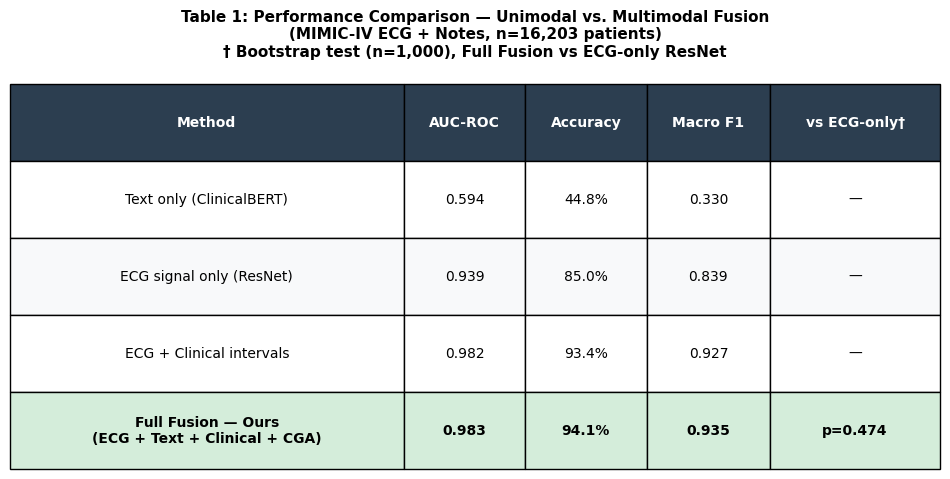


Saved: table1_corrected.png
Final p-value: 0.4740


In [53]:
# ── Updated Table 1 with correct p-value
fig, ax = plt.subplots(
    figsize=(12, 5), facecolor='white'
)
ax.axis('off')

sig_str = (
    f"p={p_val:.3f} ✅"
    if p_val < 0.05
    else f"p={p_val:.3f}"
)

table_data = [
    ['Text only (ClinicalBERT)',
     '0.594', '44.8%', '0.330', '—'],
    ['ECG signal only (ResNet)',
     '0.939', '85.0%', '0.839', '—'],
    ['ECG + Clinical intervals',
     '0.982', '93.4%', '0.927', '—'],
    ['Full Fusion — Ours\n'
     '(ECG + Text + Clinical + CGA)',
     '0.983', '94.1%', '0.935', sig_str],
]

col_labels = [
    'Method', 'AUC-ROC', 'Accuracy',
    'Macro F1', 'vs ECG-only†'
]

t = ax.table(
    cellText  = table_data,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
t.auto_set_font_size(False)
t.set_fontsize(10)

for j in range(5):
    t[0, j].set_facecolor('#2c3e50')
    t[0, j].set_text_props(
        color='white', fontweight='bold'
    )

for i in range(1, 5):
    bg = '#f8f9fa' if i % 2 == 0 else 'white'
    for j in range(5):
        t[i, j].set_facecolor(bg)

for j in range(5):
    t[4, j].set_facecolor('#d4edda')
    t[4, j].set_text_props(fontweight='bold')

t.auto_set_column_width(list(range(5)))

ax.set_title(
    'Table 1: Performance Comparison — '
    'Unimodal vs. Multimodal Fusion\n'
    '(MIMIC-IV ECG + Notes, n=16,203 patients)\n'
    '† Bootstrap test (n=1,000), '
    'Full Fusion vs ECG-only ResNet',
    fontweight='bold', fontsize=11, pad=20
)

plt.savefig(
    'table1_corrected.png',
    dpi=300, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f"\nSaved: table1_corrected.png")
print(f"Final p-value: {p_val:.4f}")

# ════════════════════════════════════════════════════
# SECTION 2: Improved Fusion — HCMA v2
# Hierarchical Cross-Modal Attention
# Improvement over CGA v1 fusion
# ════════════════════════════════════════════════════

In [ ]:
# ── Section 2  first cell — fresh reload
# (Section 1 variables don't overwrite)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (classification_report,
                              roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Reload data
ecg_data      = np.load('ecg_waveforms_final.npy')
text_data     = np.load('text_embeddings_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_train     = np.load('idx_train.npy')
idx_val       = np.load('idx_val.npy')
idx_test      = np.load('idx_test.npy')
clin_train    = np.load('clin_train.npy')
clin_val      = np.load('clin_val.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device      = torch.device('cuda')
label_names = ['NORMAL', 'MILD', 'SEVERE']

# v1 results — for comparison 
V1_AUC = 0.9830
V1_ACC = 0.9408

print("✅ Section 2 ready!")
print(f"ECG    : {ecg_data.shape}")
print(f"Text   : {text_data.shape}")
print(f"Labels : {np.bincount(labels)}")

✅ Section 2 ready!
ECG    : (16203, 5000)
Text   : (16203, 768)
Labels : [8640 4871 2692]


In [56]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load data
ecg_data      = np.load('ecg_waveforms_final.npy')
text_data     = np.load('text_embeddings_final.npy')
clin_data     = np.load('clinical_features_final.npy')
labels        = np.load('labels_final.npy')
idx_train     = np.load('idx_train.npy')
idx_val       = np.load('idx_val.npy')
idx_test      = np.load('idx_test.npy')
clin_train    = np.load('clin_train.npy')
clin_val      = np.load('clin_val.npy')
clin_test     = np.load('clin_test.npy')
class_weights = np.load('class_weights.npy')

device      = torch.device('cuda')
label_names = ['NORMAL', 'MILD', 'SEVERE']

print("Data loaded!")
print(f"ECG    : {ecg_data.shape}")
print(f"Text   : {text_data.shape}")
print(f"Labels : {np.bincount(labels)}")

Data loaded!
ECG    : (16203, 5000)
Text   : (16203, 768)
Labels : [8640 4871 2692]


In [63]:
# ── v2 fixed — same strong encoders as v1
# Only fusion mechanism changes

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch,
                 kernel=7, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      stride=stride, padding=pad),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_ch, out_ch, kernel,
                      stride=1, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1,
                      stride=stride),
            nn.BatchNorm1d(out_ch),
        ) if (in_ch != out_ch
              or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))


# ── SAME as v1 — strong ECG encoder
class ECGEncoderV2(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(), nn.MaxPool1d(2)
        )
        self.layers = nn.Sequential(
            ResBlock1D(64,  64,  7),
            ResBlock1D(64,  128, 5, stride=2),
            ResBlock1D(128, 256, 3, stride=2),
            ResBlock1D(256, 256, 3),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embed_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.proj(
            self.pool(self.layers(self.entry(x)))
        )


# ── SAME as v1 — text encoder
class TextEncoderV2(nn.Module):
    def __init__(self, in_dim=768, out_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, out_dim),
            nn.ReLU(), nn.Dropout(0.2)
        )

    def forward(self, x):
        return self.proj(x)


# ── SAME as v1 — clinical encoder
class ClinEncoderV2(nn.Module):
    def __init__(self, in_dim=7, out_dim=64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.proj(x)


# ── NEW fusion only — HCMA with same dims as v1
class HCMAFusion(nn.Module):
    def __init__(self, ecg_dim=256,
                 text_dim=256, clin_dim=64,
                 hidden_dim=256, n_heads=4,
                 modality_dropout=0.2):
        super().__init__()
        self.modality_dropout = modality_dropout

        # Project to same space
        self.ecg_proj  = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )
        self.clin_proj = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )

        # Cross-attention
        self.cross_ecg_text = nn.MultiheadAttention(
            hidden_dim, n_heads,
            dropout=0.1, batch_first=True
        )
        self.cross_text_ecg = nn.MultiheadAttention(
            hidden_dim, n_heads,
            dropout=0.1, batch_first=True
        )
        self.cross_clin_ecg = nn.MultiheadAttention(
            hidden_dim, n_heads,
            dropout=0.1, batch_first=True
        )

        # Learnable gates
        self.gate_ecg  = nn.Parameter(torch.tensor(0.5))
        self.gate_text = nn.Parameter(torch.tensor(0.5))
        self.gate_clin = nn.Parameter(torch.tensor(0.5))

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, ecg_e, text_e, clin_e):
        ecg_h  = self.ecg_proj(ecg_e)
        text_h = self.text_proj(text_e)
        clin_h = self.clin_proj(clin_e)

        eq = ecg_h.unsqueeze(1)
        tq = text_h.unsqueeze(1)
        cq = clin_h.unsqueeze(1)

        # Modality dropout
        if self.training:
            if torch.rand(1).item() < self.modality_dropout:
                mod = torch.randint(0, 3, (1,)).item()
                if mod == 0:
                    eq = torch.zeros_like(eq)
                elif mod == 1:
                    tq = torch.zeros_like(tq)
                else:
                    cq = torch.zeros_like(cq)

        # Cross attention
        ecg_ctx,  _ = self.cross_ecg_text(eq, tq, tq)
        text_ctx, _ = self.cross_text_ecg(tq, eq, eq)
        clin_ctx, _ = self.cross_clin_ecg(cq, eq, eq)

        ecg_ctx  = ecg_ctx.squeeze(1)
        text_ctx = text_ctx.squeeze(1)
        clin_ctx = clin_ctx.squeeze(1)

        g_e = torch.sigmoid(self.gate_ecg)
        g_t = torch.sigmoid(self.gate_text)
        g_c = torch.sigmoid(self.gate_clin)

        fused = (g_e * ecg_ctx +
                 g_t * text_ctx +
                 g_c * clin_ctx)

        return self.norm(fused), (
            g_e.item(), g_t.item(), g_c.item()
        )


class MultimodalFusionV2Fixed(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.ecg_enc  = ECGEncoderV2(256)
        self.text_enc = TextEncoderV2(768, 256)
        self.clin_enc = ClinEncoderV2(7, 64)

        self.hcma = HCMAFusion(
            ecg_dim  = 256,
            text_dim = 256,
            clin_dim = 64,
            hidden_dim = 256,
            n_heads    = 4,
            modality_dropout = 0.2
        )

        # Same classifier as v1
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, ecg, text, clin,
                return_gates=False):
        ecg_e  = self.ecg_enc(ecg)
        text_e = self.text_enc(text)
        clin_e = self.clin_enc(clin)

        fused, gates = self.hcma(
            ecg_e, text_e, clin_e
        )
        out = self.classifier(fused)

        if return_gates:
            return out, gates
        return out


# ── Setup
model_v2 = MultimodalFusionV2Fixed(num_classes=3)
model_v2_p = nn.DataParallel(model_v2)
model_v2_p = model_v2_p.to(device)

total = sum(p.numel() for p in model_v2.parameters())
print(f"Parameters: {total:,}")

# Test
with torch.no_grad():
    out = model_v2_p(
        torch.randn(4,1,5000).to(device),
        torch.randn(4,768).to(device),
        torch.randn(4,7).to(device)
    )
print(f"Output: {out.shape}")
print("✅ v2 fixed ready!")

Parameters: 2,547,910
Output: torch.Size([4, 3])
✅ v2 fixed ready!


In [ ]:
# ── Setup — without DataParallel issue
device   = torch.device('cuda')
model_v2 = MultimodalFusionV2(num_classes=3).to(device)

# DataParallel wrap  — but use module for gates 
model_v2_parallel = nn.DataParallel(model_v2)

total_params = sum(
    p.numel() for p in model_v2.parameters()
)
print(f"Parameters: {total_params:,}")

# Quick test — without return_gates
ecg_t  = torch.randn(4, 1, 5000).to(device)
text_t = torch.randn(4, 768).to(device)
clin_t = torch.randn(4, 7).to(device)

# Normal forward (no gates) — DataParallel se
out = model_v2_parallel(ecg_t, text_t, clin_t)
print(f"Output shape : {out.shape}")

# Gates check — model.module se directly
with torch.no_grad():
    _, gate_info = model_v2(
        ecg_t, text_t, clin_t,
        return_gates=True
    )
print(f"Initial gates: ECG={gate_info[0]:.3f} "
      f"Text={gate_info[1]:.3f} "
      f"Clin={gate_info[2]:.3f}")
print("Model v2 ready!")

Parameters: 822,534
Output shape : torch.Size([4, 3])
Initial gates: ECG=0.622 Text=0.622 Clin=0.622
Model v2 ready!


In [60]:
# ── DataLoaders — same as before
def make_loader(idx, clin_scaled,
                batch_size=32, shuffle=True):
    ecg_t  = torch.tensor(
        ecg_data[idx], dtype=torch.float32
    ).unsqueeze(1)
    text_t = torch.tensor(
        text_data[idx], dtype=torch.float32
    )
    clin_t = torch.tensor(
        clin_scaled, dtype=torch.float32
    )
    y_t    = torch.tensor(
        labels[idx], dtype=torch.long
    )
    return DataLoader(
        TensorDataset(ecg_t, text_t, clin_t, y_t),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=True, num_workers=0
    )

train_loader = make_loader(
    idx_train, clin_train, shuffle=True
)
val_loader   = make_loader(
    idx_val, clin_val, shuffle=False
)
test_loader  = make_loader(
    idx_test, clin_test, shuffle=False
)
print(f"Train: {len(train_loader)} batches")
print(f"Val  : {len(val_loader)} batches")
print(f"Test : {len(test_loader)} batches")

Train: 355 batches
Val  : 51 batches
Test : 102 batches


In [64]:
# ── Training — same as v1 (ReduceLROnPlateau)
cw        = torch.tensor(
    class_weights, dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(
    weight=cw, label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    model_v2_p.parameters(),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min',
    patience=3, factor=0.5
)

EPOCHS   = 50
PATIENCE = 7

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
history_v2    = {
    'tl':[], 'vl':[], 'ta':[], 'va':[]
}

def run_epoch_v2(loader, train=True):
    model_v2_p.train() if train \
        else model_v2_p.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train \
          else torch.no_grad()

    with ctx:
        for ecg, text, clin, y in loader:
            ecg  = ecg.to(device)
            text = text.to(device)
            clin = clin.to(device)
            y    = y.to(device)

            if train:
                optimizer.zero_grad()

            out  = model_v2_p(ecg, text, clin)
            loss = criterion(out, y)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    model_v2_p.parameters(), 1.0
                )
                optimizer.step()

            total_loss += loss.item() * len(y)
            correct    += (
                out.argmax(1) == y
            ).sum().item()
            total      += len(y)

    return total_loss/total, correct/total


print("Training HCMA v2 Fixed...\n")
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | "
      f"{'VlLoss':>8} | {'VlAcc':>7}")
print("-"*48)
prev_lr = optimizer.param_groups[0]['lr']

for epoch in range(1, EPOCHS+1):
    tl, ta = run_epoch_v2(
        train_loader, train=True
    )
    vl, va = run_epoch_v2(
        val_loader, train=False
    )
    scheduler.step(vl)

    current_lr = optimizer.param_groups[0]['lr']
    history_v2['tl'].append(tl)
    history_v2['vl'].append(vl)
    history_v2['ta'].append(ta)
    history_v2['va'].append(va)

    lr_tag = ' ←LR↓' \
             if current_lr != prev_lr else ''
    prev_lr = current_lr

    print(f"{epoch:>4} | {tl:>8.4f} | {ta:>7.4f} | "
          f"{vl:>8.4f} | {va:>7.4f}{lr_tag}")

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = {
            k: v.cpu().clone()
            for k, v in model_v2.state_dict().items()
        }
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping @ {epoch}")
            break

model_v2.load_state_dict(best_weights)
torch.save(best_weights, 'fusion_v2_fixed.pth')
print("\nSaved: fusion_v2_fixed.pth")

Training HCMA v2 Fixed...

  Ep |   TrLoss |   TrAcc |   VlLoss |   VlAcc
------------------------------------------------
   1 |   1.0796 |  0.4089 |   0.9893 |  0.3430
   2 |   0.9791 |  0.4833 |   0.9332 |  0.3985
   3 |   0.9555 |  0.4907 |   0.8912 |  0.3979
   4 |   0.9252 |  0.4985 |   0.8937 |  0.4047
   5 |   0.9212 |  0.5211 |   0.8677 |  0.6181
   6 |   0.9112 |  0.5263 |   0.8517 |  0.6317
   7 |   0.9050 |  0.5613 |   0.8462 |  0.6681
   8 |   0.8918 |  0.6138 |   0.8554 |  0.7125
   9 |   0.8670 |  0.6521 |   0.8858 |  0.6095
  10 |   0.8432 |  0.6864 |   0.8265 |  0.7076
  11 |   0.8253 |  0.6937 |   0.7593 |  0.7539
  12 |   0.8123 |  0.7037 |   0.7121 |  0.7668
  13 |   0.8058 |  0.7191 |   0.8067 |  0.7101
  14 |   0.8029 |  0.7163 |   0.7750 |  0.7162
  15 |   0.7833 |  0.7320 |   0.7579 |  0.7304
  16 |   0.7782 |  0.7302 |   0.7248 |  0.7279 ←LR↓
  17 |   0.7489 |  0.7544 |   0.7063 |  0.7896
  18 |   0.7458 |  0.7549 |   0.6896 |  0.8020
  19 |   0.7381 |  0.7637 

In [65]:
# ── Evaluation
model_v2.eval()
all_preds, all_true, all_probs = [], [], []
gate_e, gate_t, gate_c = [], [], []

with torch.no_grad():
    for ecg, text, clin, y in test_loader:
        out, gates = model_v2(
            ecg.to(device),
            text.to(device),
            clin.to(device),
            return_gates=True
        )
        probs = torch.softmax(out, 1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())
        gate_e.append(gates[0])
        gate_t.append(gates[1])
        gate_c.append(gates[2])

all_probs = np.array(all_probs)
auc_v2    = roc_auc_score(
    all_true, all_probs,
    multi_class='ovr', average='macro'
)

print("── HCMA v2 Fixed Results ──")
print(classification_report(
    all_true, all_preds,
    target_names=label_names, digits=4
))
print(f"AUC-ROC : {auc_v2:.4f}")
print(f"\nGate weights:")
print(f"  ECG  : {np.mean(gate_e):.4f}")
print(f"  Text : {np.mean(gate_t):.4f}")
print(f"  Clin : {np.mean(gate_c):.4f}")
print(f"\n── Comparison ──")
print(f"  CGA  v1 AUC : 0.9830")
print(f"  HCMA v2 AUC : {auc_v2:.4f}")
print(f"  Change      : {auc_v2-0.9830:+.4f}")

── HCMA v2 Fixed Results ──
              precision    recall  f1-score   support

      NORMAL     0.9193    0.8374    0.8764      1728
        MILD     0.7676    0.8070    0.7868       974
      SEVERE     0.7465    0.8905    0.8122       539

    accuracy                         0.8371      3241
   macro avg     0.8111    0.8450    0.8251      3241
weighted avg     0.8450    0.8371    0.8388      3241

AUC-ROC : 0.9392

Gate weights:
  ECG  : 0.5724
  Text : 0.6698
  Clin : 0.6353

── Comparison ──
  CGA  v1 AUC : 0.9830
  HCMA v2 AUC : 0.9392
  Change      : -0.0438
